<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   S. No.                  50 non-null     int64  
 1   Percentage in Grade 10  50 non-null     float64
 2   Salary                  50 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.3 KB
const                     30587.285652
Percentage in Grade 10     3560.587383
dtype: float64
                          Results: Ordinary least squares
Model:                    OLS                   Adj. R-squared:          0.190     
Dependent Variable:       Salary                AIC:                     1008.8680 
Date:                     2026-03-25 21:21      BIC:                     1012.2458 
No. Observations:         40                    Log-Likelihood:          -502.43   
Df Model:                 1                     F-statistic:             10.16     
Df Residuals:          

<Figure size 800x600 with 0 Axes>

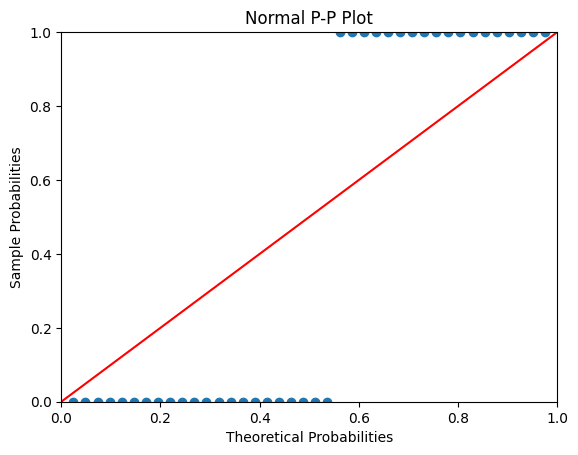

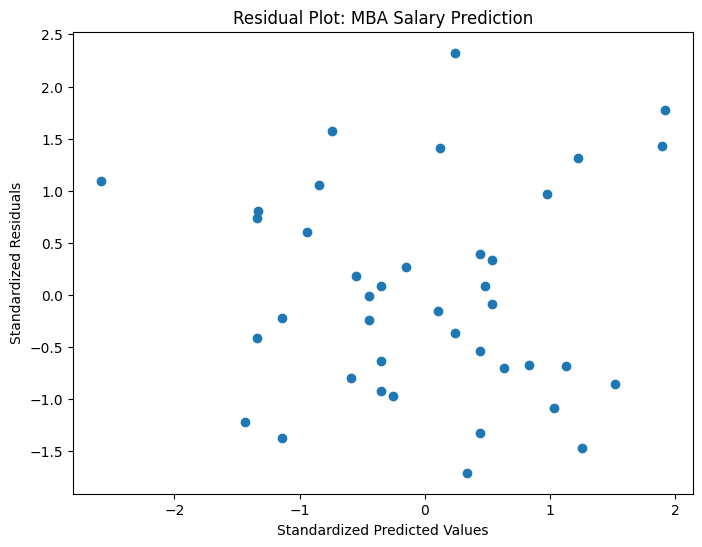

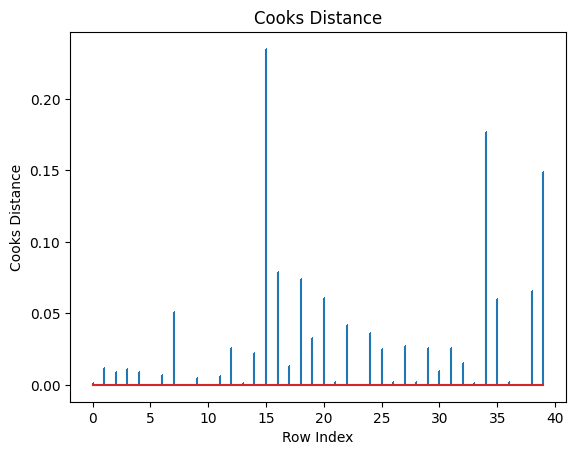

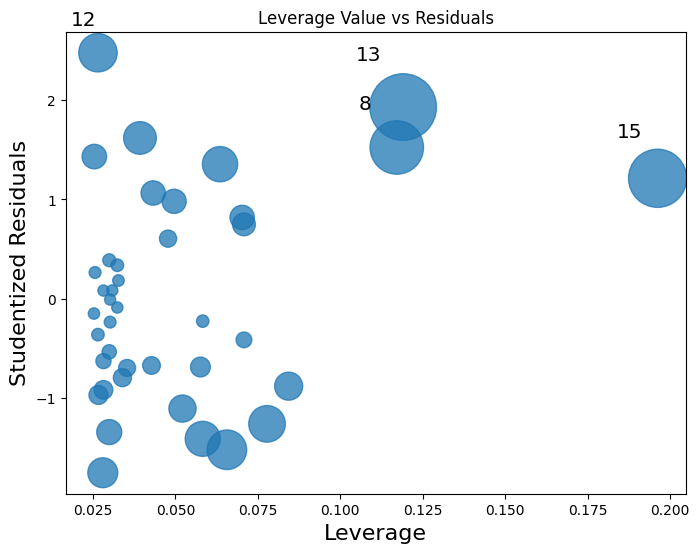


Model Evaluation:
R² Score: -0.156645849742304
RMSE: 73458.04348346895


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the dataset
mba_salary_df = pd.read_csv('MBA Salary.csv')
mba_salary_df.info()

# Define features and target
X = sm.add_constant(mba_salary_df['Percentage in Grade 10'])
Y = mba_salary_df['Salary']

# Split the data
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, train_size=0.8, random_state=100)

# Build and fit the model
mba_salary_lm = sm.OLS(train_Y, train_X).fit()

# View model parameters and summary
print(mba_salary_lm.params)
print(mba_salary_lm.summary2())

intercept = mba_salary_lm.params['const']
slope = mba_salary_lm.params['Percentage in Grade 10']

print("\nRegression Equation:")
print(f"Salary = {intercept} + {slope} * (Percentage in Grade 10)")

print(f"\nFor every 1% increase in Grade 10 marks, salary increases by {slope:.4f}")
print(f"Intercept (baseline salary): {intercept:.4f}")

# Residuals
residuals = mba_salary_lm.resid

# Normal Distribution of Residual
probplot = sm.ProbPlot(residuals)

plt.figure(figsize=(8, 6))
probplot.ppplot(line='45')
plt.title("Normal P-P Plot")
plt.show()

# Homoacedasticity

def get_standardized_values(vals):
    return (vals - vals.mean()) / vals.std()

plt.figure(figsize=(8, 6))
plt.scatter(
    get_standardized_values(mba_salary_lm.fittedvalues),
    get_standardized_values(residuals)
)
plt.title("Residual Plot: MBA Salary Prediction")
plt.xlabel("Standardized Predicted Values")
plt.ylabel("Standardized Residuals")
plt.show()

# Outlier analysis

from scipy.stats import zscore
from statsmodels.graphics.regressionplots import influence_plot
from sklearn.metrics import r2_score,mean_squared_error

# Z-Score Analysis
mba_salary_df['z_score_salary'] = zscore(mba_salary_df.Salary)
outliers = mba_salary_df[(mba_salary_df.z_score_salary > 3.0) | (mba_salary_df.z_score_salary < -3.0)]

# Cook's Distance
mba_influence = mba_salary_lm.get_influence()
(c, p) = mba_influence.cooks_distance
plt.stem(np.arange(len(train_X)), np.round(c, 3), markerfmt=",")
plt.title('Cooks Distance')
plt.xlabel('Row Index')
plt.ylabel('Cooks Distance')
plt.show()

# Leverage Plot
fig, ax = plt.subplots(figsize=(8, 6))
influence_plot(mba_salary_lm, ax=ax)
plt.title('Leverage Value vs Residuals')
plt.show()

# Model Evaluation
# ================================

pred_y = mba_salary_lm.predict(test_X)

r2 = r2_score(test_Y, pred_y)
rmse = np.sqrt(mean_squared_error(test_Y, pred_y))

print("\nModel Evaluation:")
print("R² Score:", r2)
print("RMSE:", rmse)

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the dataset
mba_salary_df = pd.read_csv('MBA Salary.csv')
mba_salary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   S. No.                  50 non-null     int64  
 1   Percentage in Grade 10  50 non-null     float64
 2   Salary                  50 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.3 KB


In [8]:
# Define features and target
X = sm.add_constant(mba_salary_df['Percentage in Grade 10'])
Y = mba_salary_df['Salary']

In [9]:
# Split the data
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, train_size=0.8, random_state=100)

In [10]:
# Build and fit the model
mba_salary_lm = sm.OLS(train_Y, train_X).fit()

In [13]:
# View model parameters and summary
print(mba_salary_lm.params)
print(mba_salary_lm.summary2())

const                     30587.285652
Percentage in Grade 10     3560.587383
dtype: float64
                          Results: Ordinary least squares
Model:                    OLS                   Adj. R-squared:          0.190     
Dependent Variable:       Salary                AIC:                     1008.8680 
Date:                     2026-03-25 21:06      BIC:                     1012.2458 
No. Observations:         40                    Log-Likelihood:          -502.43   
Df Model:                 1                     F-statistic:             10.16     
Df Residuals:             38                    Prob (F-statistic):      0.00287   
R-squared:                0.211                 Scale:                   5.0121e+09
-----------------------------------------------------------------------------------
                         Coef.     Std.Err.    t    P>|t|     [0.025       0.975]  
-----------------------------------------------------------------------------------
const    

In [14]:
intercept = mba_salary_lm.params['const']
slope = mba_salary_lm.params['Percentage in Grade 10']

In [21]:
print("\nRegression Equation:")
print(f"Salary = {intercept} + {slope} * (Percentage in Grade 10)")
print(f"\nFor every 1% increase in Grade 10 marks, salary increases by {slope:.2f}")
print(f"Intercept (baseline salary): {intercept:.4f}")


Regression Equation:
Salary = 30587.285651523373 + 3560.587382863203 * (Percentage in Grade 10)

For every 1% increase in Grade 10 marks, salary increases by 3560.59
Intercept (baseline salary): 30587.2857


In [22]:
# Residuals
residuals = mba_salary_lm.resid

# Normal Distribution of Residual
probplot = sm.ProbPlot(residuals)

<Figure size 800x600 with 0 Axes>

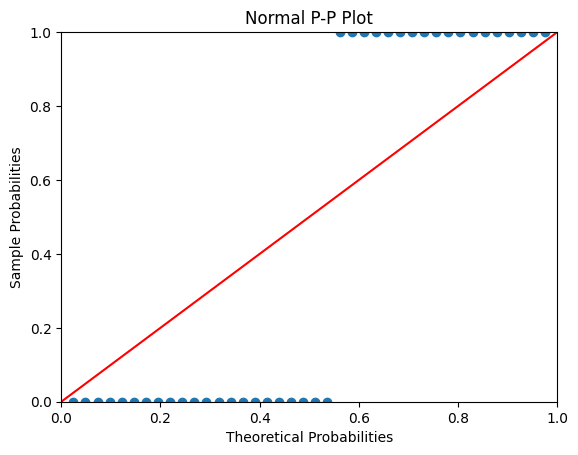

In [27]:
plt.figure(figsize=(8, 6))
probplot.ppplot(line='45')
plt.title("Normal P-P Plot")
plt.show()

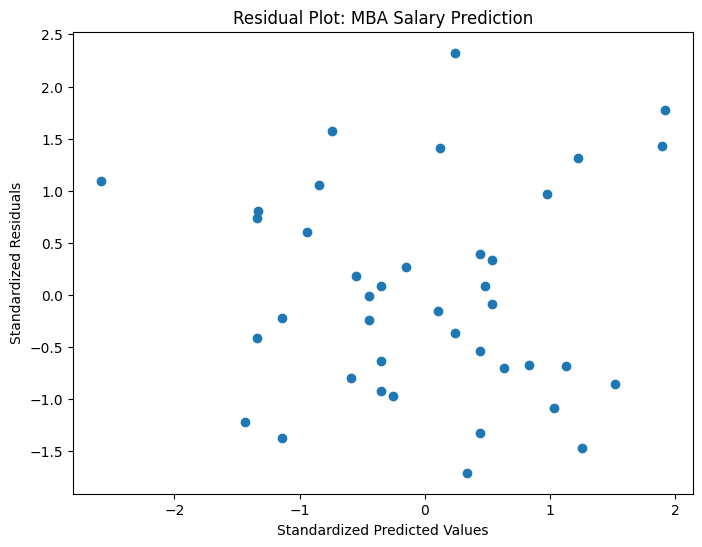

In [28]:
# Homoacedasticity

def get_standardized_values(vals):
    return (vals - vals.mean()) / vals.std()

plt.figure(figsize=(8, 6))
plt.scatter(
    get_standardized_values(mba_salary_lm.fittedvalues),
    get_standardized_values(residuals)
)
plt.title("Residual Plot: MBA Salary Prediction")
plt.xlabel("Standardized Predicted Values")
plt.ylabel("Standardized Residuals")
plt.show()

In [1]:
# Z-Score Analysis
mba_salary_df['z_score_salary'] = zscore(mba_salary_df.Salary)
outliers = mba_salary_df[(mba_salary_df.z_score_salary > 3.0) | (mba_salary_df.z_score_salary < -3.0)]

NameError: name 'zscore' is not defined

In [1]:
# Cook's Distance
mba_influence = mba_salary_lm.get_influence()
print(mba_influence)
(c, p) = mba_influence.cooks_distance
plt.stem(c,markerfmt=',')
plt.title('Cooks Distance')
plt.xlabel('Row Index')
plt.ylabel('Cooks Distance')
plt.show()

NameError: name 'mba_salary_lm' is not defined

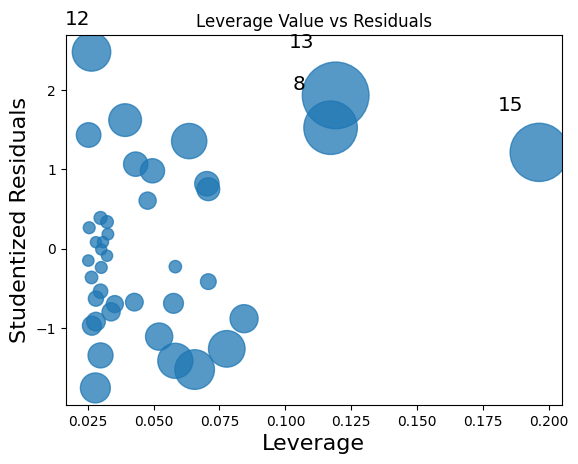

In [17]:
# Leverage Plot
fig, ax = plt.subplots(figsize=(8, 6))
influence_plot(mba_salary_lm)
plt.title('Leverage Value vs Residuals')
plt.show()

In [21]:
pred_y = mba_salary_lm.predict(test_X)
print(pred_y)
r2 = r2_score(test_Y, pred_y)
rmse = np.sqrt(mean_squared_error(test_Y, pred_y))

print("\nModel Evaluation:")
print("R² Score:", r2)
print("RMSE:", rmse)

6     279828.402452
36    272707.227686
37    215737.829560
28    237101.353858
43    295851.045675
49    247070.998530
5     226419.591709
33    308313.101515
20    254904.290772
42    295494.986937
dtype: float64

Model Evaluation:
R² Score: -0.156645849742304
RMSE: 73458.04348346895


In [ ]:
print(np.-0.156645849742304